# Home Credit Default Risk — Exploratory Data Analysis

**Phase 3** of the Credit Risk / Loan Default Predictor portfolio project.

Dataset: [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle).
No modeling happens in this notebook. The goal is purely to understand the data well
enough to make good feature-engineering and modeling decisions later, and to write down
concrete hypotheses we can check against SHAP explanations once a model exists.

**Reference points** (for context, not to copy): two public solutions to this competition. `kozodoi/Kaggle_Home_Credit` (top-4%, ~0.79-0.80 AUC via heavy feature engineering +
LightGBM ensembling) and `NoxMoon/home-credit-default-risk` (downsampling for class
imbalance + GRU features from the time-series tables). Both treat the auxiliary tables
(bureau, previous applications, credit card balances) as a major source of signal, and both
find the `EXT_SOURCE_*` columns to be dominant predictors. This EDA checks whether those
patterns hold in the raw data before we build anything.


## Setup

Standard imports. We set a larger default figure size and font scale up front because
several plots in this notebook are meant to be **impossible to miss** at a glance (the
class imbalance chart especially) — this is a deliberate readability choice, not styling
for its own sake.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 200)

DATA_DIR = "data/raw"


## 1. Load the data

We load four tables for this EDA pass, not all fourteen the competition provides:

- **`application_train.csv`** — one row per loan application, with the label (`TARGET`:
  1 = defaulted, 0 = repaid) and applicant-level features (income, employment, family,
  the `EXT_SOURCE_*` bureau scores, etc.). This is the main table everything else joins
  onto via `SK_ID_CURR`.
- **`bureau.csv`** — every credit the applicant has (or had) at *other* financial
  institutions, reported to the credit bureau. One applicant can have many rows here.
- **`previous_application.csv`** — the applicant's own prior loan applications with Home
  Credit specifically (approved, refused, cancelled, etc.).
- **`credit_card_balance.csv`** — monthly balance snapshots for any Home Credit credit
  cards the applicant holds.

We're skipping `bureau_balance.csv`, `POS_CASH_balance.csv`, and `installments_payments.csv`
for this EDA pass — they're large monthly-snapshot tables that matter a lot for *feature
engineering* (Phase 4) but aren't needed to establish the core EDA findings (imbalance,
missingness, and which applicant-level variables look predictive).


In [2]:
app = pd.read_csv(f"{DATA_DIR}/application_train.csv")
bureau = pd.read_csv(f"{DATA_DIR}/bureau.csv")
previous = pd.read_csv(f"{DATA_DIR}/previous_application.csv")
credit_card = pd.read_csv(f"{DATA_DIR}/credit_card_balance.csv")

print("application_train: ", app.shape)
print("bureau:            ", bureau.shape)
print("previous_application:", previous.shape)
print("credit_card_balance:", credit_card.shape)


application_train:  (307511, 122)
bureau:             (1716428, 17)
previous_application: (1670214, 37)
credit_card_balance: (3840312, 23)


## 2. Class imbalance

**Plain English:** "class imbalance" means the thing we're trying to predict (default vs.
no default) doesn't split anywhere close to 50/50. Here, roughly 1 in 12 applicants
defaults. That sounds like a minor detail, but it changes almost everything about how we
approach modeling:

- A model that **always predicts "no default"** would already be ~92% "accurate" — and
  completely useless, since it would approve every risky applicant. This means **accuracy
  is not a usable metric** for this problem. We'll need AUC-ROC and precision/recall (or
  PR-AUC) instead, which is why both reference solutions report AUC rather than accuracy.
- Many models (and loss functions) implicitly assume a roughly balanced target and will
  happily learn to mostly predict the majority class unless we do something about it
  (class weighting, resampling, or a calibration step) — this is exactly the problem the
  `NoxMoon` reference solution addresses head-on with per-fold downsampling.
- Later, when we calibrate the model (Phase 5), imbalance is also why raw predicted
  probabilities can't be trusted at face value without checking calibration curves.

This is worth internalizing now because it will justify modeling choices several phases
from now that would otherwise look arbitrary.


Counts:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentages:
 TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


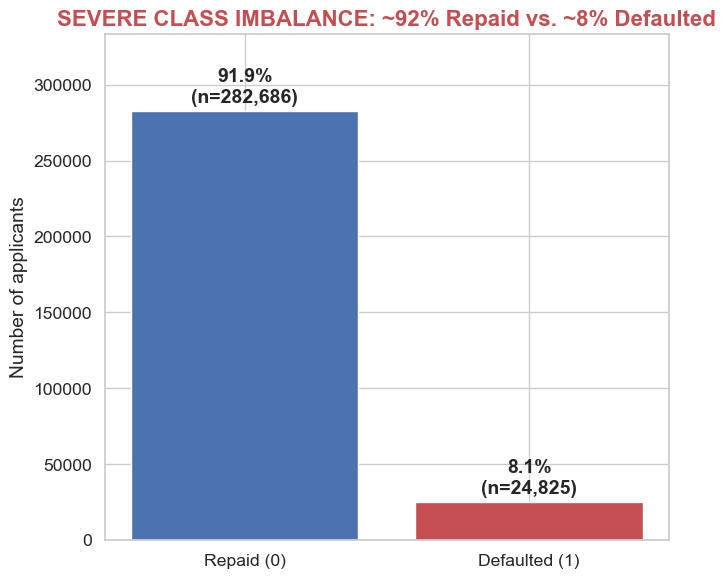

In [3]:
target_counts = app["TARGET"].value_counts().sort_index()
target_pct = app["TARGET"].value_counts(normalize=True).sort_index() * 100

print("Counts:\n", target_counts)
print("\nPercentages:\n", target_pct.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#4C72B0", "#C44E52"]
bars = ax.bar(["Repaid (0)", "Defaulted (1)"], target_counts.values, color=colors)

for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
            f"{pct:.1f}%\n(n={int(bar.get_height()):,})",
            ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.set_title("SEVERE CLASS IMBALANCE: ~92% Repaid vs. ~8% Defaulted",
              fontsize=16, fontweight="bold", color="#C44E52")
ax.set_ylabel("Number of applicants")
ax.set_ylim(0, target_counts.max() * 1.18)
plt.tight_layout()
plt.show()


**Takeaway:** ~8.1% of applicants in the training set defaulted (`TARGET == 1`). Keep this
number in your head for every metric we report from here on. An unweighted accuracy
figure anywhere in this project should be treated with suspicion.


## 3. Missing data analysis

There are different *reasons* a value can be missing, and the reason matters for how we handle it:

- **Missing completely at random (MCAR):** the blank is just noise, e.g. a form field
  someone forgot to fill in for no systematic reason. Safe to impute with a simple
  strategy (mean/median/mode) without much risk of introducing bias.
- **Missing not at random / missingness is itself informative (MNAR):** the *fact that
  the value is missing* is correlated with the outcome we're predicting. For example, a
  first-time borrower has no credit bureau history to report, so bureau-derived columns
  are missing *because* they're new to credit, which is itself a risk-relevant fact. If we
  silently impute these away, we throw away signal. The right move is often to keep an
  explicit "was this missing?" indicator column alongside the imputed value.

We check both: which columns are missing and how much, and then specifically test the
bureau-history hypothesis, since it's a concrete, checkable example of case two.


67 of 122 columns in application_train have missing values.

Top 15 most-missing columns:
COMMONAREA_MEDI             69.87
COMMONAREA_AVG              69.87
COMMONAREA_MODE             69.87
NONLIVINGAPARTMENTS_MODE    69.43
NONLIVINGAPARTMENTS_AVG     69.43
NONLIVINGAPARTMENTS_MEDI    69.43
FONDKAPREMONT_MODE          68.39
LIVINGAPARTMENTS_MODE       68.35
LIVINGAPARTMENTS_AVG        68.35
LIVINGAPARTMENTS_MEDI       68.35
FLOORSMIN_AVG               67.85
FLOORSMIN_MODE              67.85
FLOORSMIN_MEDI              67.85
YEARS_BUILD_MEDI            66.50
YEARS_BUILD_MODE            66.50
dtype: float64


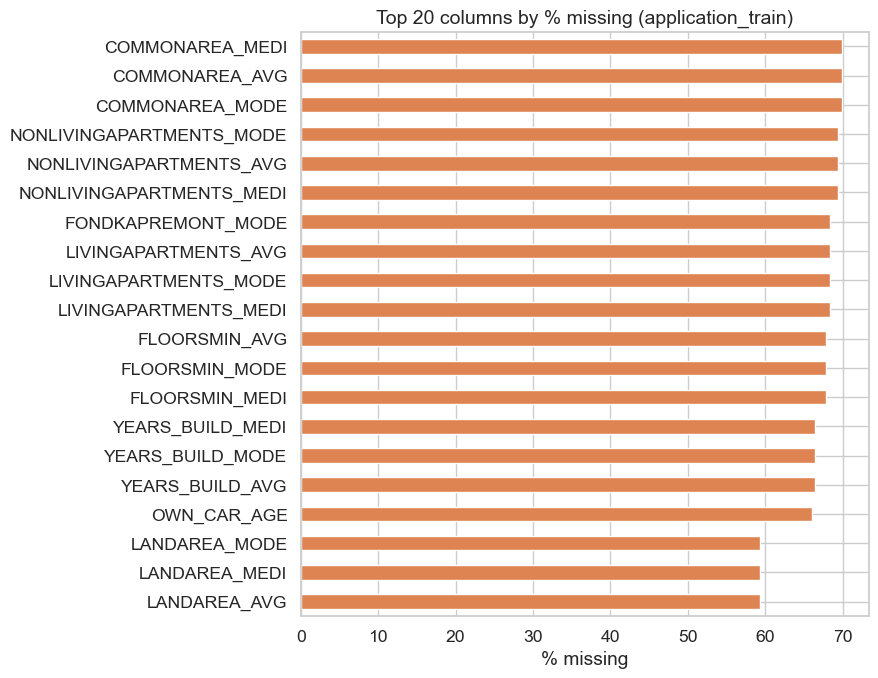

In [4]:
missing_pct = app.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

print(f"{len(missing_pct)} of {app.shape[1]} columns in application_train have missing values.")
print("\nTop 15 most-missing columns:")
print(missing_pct.head(15).round(2))

fig, ax = plt.subplots(figsize=(9, 7))
missing_pct.head(20).sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Top 20 columns by % missing (application_train)", fontsize=14)
ax.set_xlabel("% missing")
plt.tight_layout()
plt.show()


Most of the worst offenders (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`,
`FLOORSMIN_*`, `YEARS_BUILD_*`) are building/apartment-attribute columns. These look like
they're missing whenever the applicant's housing type doesn't have that attribute at all
(e.g. renters have no "common area size"), which is closer to MCAR/structural missingness
than a risk signal. The more interesting case is the bureau history, tested below.


Applicants WITH bureau history:    263,491 (85.7%)
Applicants WITHOUT bureau history: 44,020 (14.3%)

Default rate WITH bureau history:    7.73%
Default rate WITHOUT bureau history: 10.12%


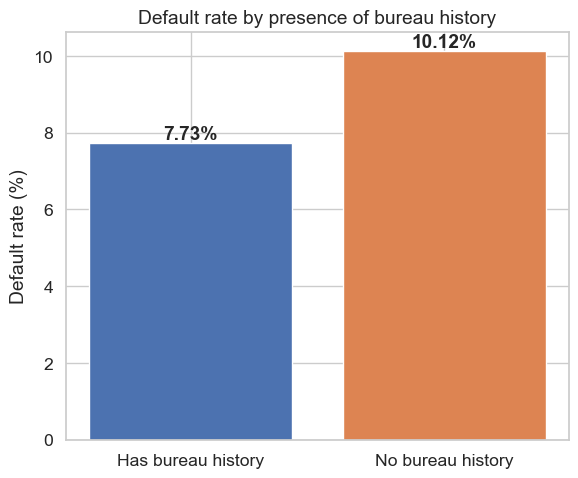

In [5]:
has_bureau_history = app["SK_ID_CURR"].isin(bureau["SK_ID_CURR"].unique())

print(f"Applicants WITH bureau history:    {has_bureau_history.sum():,} "
      f"({has_bureau_history.mean()*100:.1f}%)")
print(f"Applicants WITHOUT bureau history: {(~has_bureau_history).sum():,} "
      f"({(~has_bureau_history).mean()*100:.1f}%)")
print()
print(f"Default rate WITH bureau history:    {app.loc[has_bureau_history, 'TARGET'].mean()*100:.2f}%")
print(f"Default rate WITHOUT bureau history: {app.loc[~has_bureau_history, 'TARGET'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 5))
rates = [app.loc[has_bureau_history, "TARGET"].mean() * 100,
         app.loc[~has_bureau_history, "TARGET"].mean() * 100]
ax.bar(["Has bureau history", "No bureau history"], rates, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by presence of bureau history")
for i, r in enumerate(rates):
    ax.text(i, r + 0.1, f"{r:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


**Confirmed. This is exactly the informative-missingness case.** Applicants with *no*
bureau record default at a noticeably higher rate (~10.1%) than those with a bureau record
(~7.7%). That's consistent with "no credit history" (first-time or thin-file borrowers)
being genuinely riskier, not just a data-entry gap. This means in Phase 4 we should
engineer an explicit `HAS_BUREAU_HISTORY` flag rather than only relying on aggregated
bureau features that would silently be zero/NaN for this group.


### A related, well-known quirk: `DAYS_EMPLOYED`

This isn't a *missing*-data issue technically (no NaNs), but it's the same category of
problem: a sentinel value standing in for something structural. `DAYS_EMPLOYED` is negative
for currently-employed people (days before the application date), but a chunk of the
column is fixed at exactly **365243** — about 1,000 years. That's not a real value; it's a
placeholder, almost certainly for applicants who are **not currently employed** (e.g.
retirees/pensioners), where "days employed" doesn't apply.


count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Applicants at the 365243 sentinel: 55,374 (18.01%)
Default rate for sentinel group:     5.40%
Default rate for everyone else:      8.66%


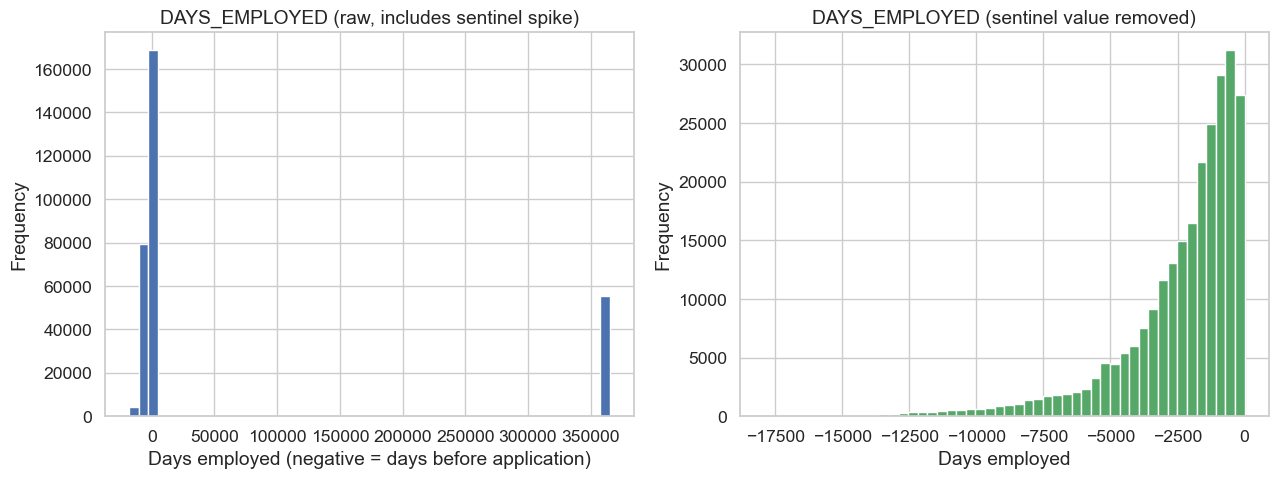

In [6]:
print(app["DAYS_EMPLOYED"].describe())

anomaly = app["DAYS_EMPLOYED"] == 365243
print(f"\nApplicants at the 365243 sentinel: {anomaly.sum():,} ({anomaly.mean()*100:.2f}%)")
print(f"Default rate for sentinel group:     {app.loc[anomaly, 'TARGET'].mean()*100:.2f}%")
print(f"Default rate for everyone else:      {app.loc[~anomaly, 'TARGET'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
app["DAYS_EMPLOYED"].plot(kind="hist", bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("DAYS_EMPLOYED (raw, includes sentinel spike)")
axes[0].set_xlabel("Days employed (negative = days before application)")

app.loc[~anomaly, "DAYS_EMPLOYED"].plot(kind="hist", bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("DAYS_EMPLOYED (sentinel value removed)")
axes[1].set_xlabel("Days employed")
plt.tight_layout()
plt.show()


As suspected: the sentinel group has a *lower* default rate (~5.4%) than everyone else
(~8.7%), consistent with it representing retirees/pensioners, a group Home Credit
apparently underwrites as relatively safe. **Action item for Phase 4:** replace 365243
with NaN (so it doesn't get treated as a real numeric value. A raw model would otherwise
read "employed for 1000 years" as a huge, meaningless number) and add an explicit
`IS_DAYS_EMPLOYED_ANOMALY` flag, since the flag itself carries signal.


## 4. Univariate plots — variables likely to matter

We look at six variables here: applicant income, credit amount requested, days employed
(cleaned), and all three `EXT_SOURCE_*` bureau scores. The `EXT_SOURCE_*` columns deserve
context if you haven't seen this dataset before:

**What are `EXT_SOURCE_1/2/3`?** They're normalized (roughly 0–1) credit-worthiness scores
computed by external data sources/bureaus and handed to Home Credit. Conceptually similar
to a FICO score, but from third parties, and Home Credit doesn't tell us exactly how each
is computed. The reason they show up as the top features in nearly every public analysis
of this dataset is intuitive once you say it plainly: **someone else already built a
predictive credit model on this applicant, and gave us its output as a feature.** We're
not competing with that signal from scratch. We're trying to add value on top of it via
better feature engineering from the auxiliary tables. That's exactly the bar both
reference solutions set, so it's worth confirming this holds here before we lean on it.


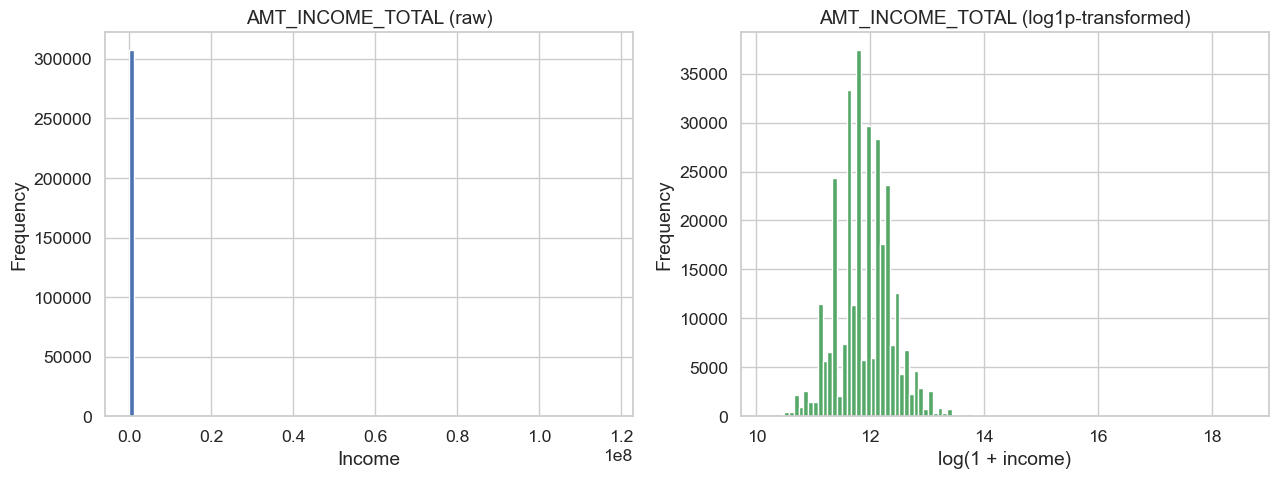

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
app["AMT_INCOME_TOTAL"].plot(kind="hist", bins=100, ax=ax[0], color="#4C72B0")
ax[0].set_title("AMT_INCOME_TOTAL (raw)")
ax[0].set_xlabel("Income")

np.log1p(app["AMT_INCOME_TOTAL"]).plot(kind="hist", bins=100, ax=ax[1], color="#55A868")
ax[1].set_title("AMT_INCOME_TOTAL (log1p-transformed)")
ax[1].set_xlabel("log(1 + income)")
plt.tight_layout()
plt.show()

print(app["AMT_INCOME_TOTAL"].describe())


Income is extremely right-skewed with at least one massive outlier (the max is ~117
million against a median around 147k). A single applicant is skewing the raw
distribution so hard it's unreadable. The log-transformed version on the right is far
closer to usable for a model, or at minimum this column needs outlier
capping/winsorization in Phase 4.


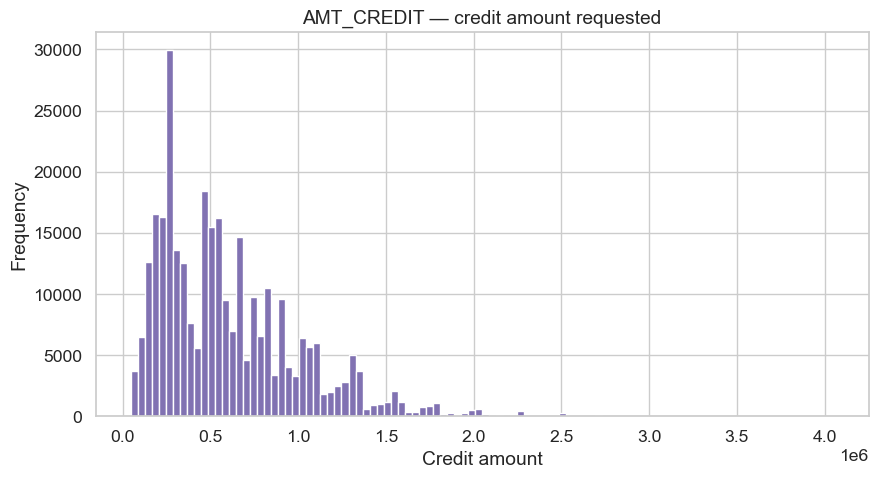

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
app["AMT_CREDIT"].plot(kind="hist", bins=100, ax=ax, color="#8172B2")
ax.set_title("AMT_CREDIT — credit amount requested")
ax.set_xlabel("Credit amount")
plt.tight_layout()
plt.show()

print(app["AMT_CREDIT"].describe())


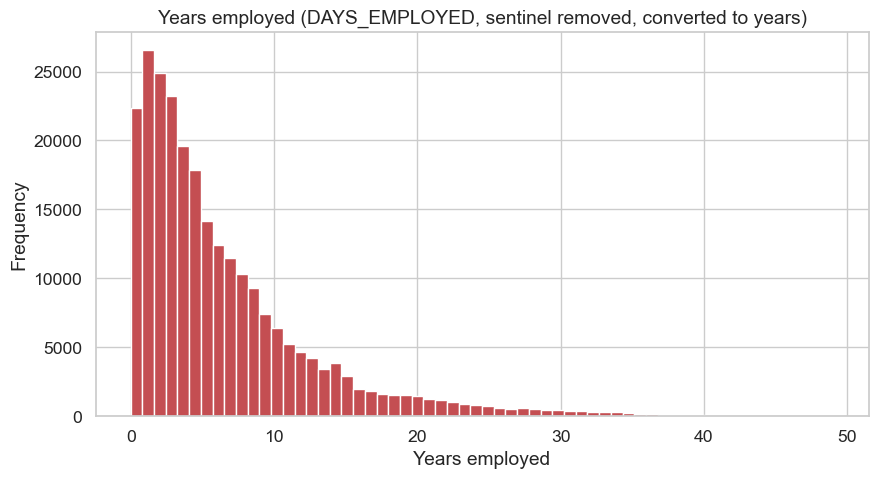

In [9]:
clean_days_employed = app.loc[~anomaly, "DAYS_EMPLOYED"]
fig, ax = plt.subplots(figsize=(9, 5))
(-clean_days_employed / 365.25).plot(kind="hist", bins=60, ax=ax, color="#C44E52")
ax.set_title("Years employed (DAYS_EMPLOYED, sentinel removed, converted to years)")
ax.set_xlabel("Years employed")
plt.tight_layout()
plt.show()


### EXT_SOURCE_1/2/3, split by TARGET

For these three we plot the distribution separately for defaulters vs. non-defaulters
(rather than just the overall shape) because what we actually care about is whether the
score *separates* the two classes. That's what would make it useful to a model, and it's
the most direct visual check of the "these are the top predictors" claim before we compute
a model.


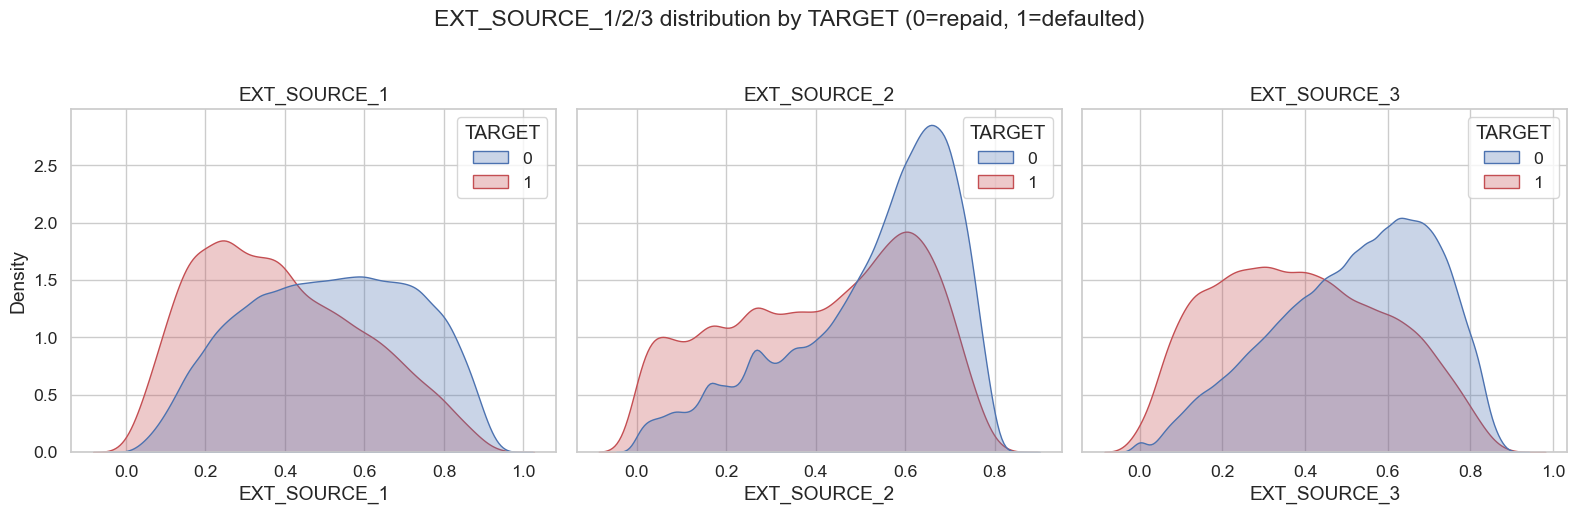

Missingness:
EXT_SOURCE_1    56.38
EXT_SOURCE_2     0.21
EXT_SOURCE_3    19.83
dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for i, col in enumerate(["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    sns.kdeplot(data=app, x=col, hue="TARGET", ax=axes[i], common_norm=False,
                palette={0: "#4C72B0", 1: "#C44E52"}, fill=True, alpha=0.3)
    axes[i].set_title(col)
plt.suptitle("EXT_SOURCE_1/2/3 distribution by TARGET (0=repaid, 1=defaulted)", y=1.03)
plt.tight_layout()
plt.show()

missing_ext = app[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].isnull().mean() * 100
print("Missingness:")
print(missing_ext.round(2))


Visually, defaulters (red) are shifted noticeably toward lower `EXT_SOURCE` values in all
three, with `EXT_SOURCE_3` and `EXT_SOURCE_2` showing the clearest separation (also the two
with the strongest raw linear correlation to `TARGET` — see the correlation check below).
Note the missingness pattern too: `EXT_SOURCE_1` is missing more than half the time and
`EXT_SOURCE_3` about a fifth of the time, while `EXT_SOURCE_2` is almost always present —
so in Phase 4 we'll want missing-indicator flags for `EXT_SOURCE_1`/`_3` specifically,
plus an aggregate (e.g. mean of available scores) as a fallback feature for rows missing
one or more.

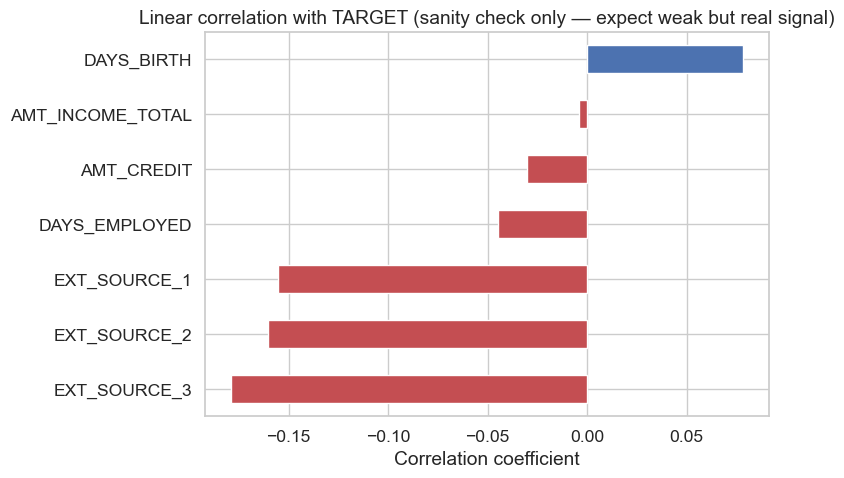

EXT_SOURCE_3       -0.1789
EXT_SOURCE_2       -0.1605
EXT_SOURCE_1       -0.1553
DAYS_EMPLOYED      -0.0449
AMT_CREDIT         -0.0304
AMT_INCOME_TOTAL   -0.0040
DAYS_BIRTH          0.0782
Name: TARGET, dtype: float64


In [11]:
check_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
              "AMT_INCOME_TOTAL", "AMT_CREDIT", "DAYS_EMPLOYED", "DAYS_BIRTH"]
corr_with_target = app[check_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind="barh", ax=ax, color=["#C44E52" if v < 0 else "#4C72B0" for v in corr_with_target])
ax.set_title("Linear correlation with TARGET (sanity check only — expect weak but real signal)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print(corr_with_target.round(4))


**Confirms the hypothesis from the reference solutions:** the three `EXT_SOURCE_*` columns
are the strongest linear correlates with `TARGET` among the variables checked here (all
~-0.16 to -0.18 — negative because a *higher* external score means *lower* default risk),
clearly outranking raw income, credit amount, and employment length. None of these
correlations are large in absolute terms (this is a genuinely hard prediction problem,
which is exactly why the top Kaggle score across ~7,000 teams tops out around 0.80 AUC
rather than something close to 1.0) — but the *relative* ranking matches what both
reference solutions report, which is reassuring: it means the well-known result isn't a
Kaggle-specific artifact, it's a real pattern in this data.


## Hypotheses to check against SHAP later

Written down now, before any model exists, so we have something concrete to compare
against once we compute SHAP values in Phase 6. If SHAP disagrees with any of these,
that's a signal worth digging into rather than dismissing.

1. **`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` will be among the top few most
   important features**, consistent with both reference solutions and the correlation
   check above. Raw correlation with `TARGET` ranks `EXT_SOURCE_3` strongest (-0.179),
   then `EXT_SOURCE_2` (-0.160), then `EXT_SOURCE_1` weakest (-0.155) — so on linear
   signal alone I'd expect `_3` and `_2` to edge out `_1`. But `EXT_SOURCE_1` is missing
   56% of the time vs. 20% for `_3` and 0.2% for `_2`, so a tree model only ever sees a
   real (non-imputed) value for `_1` on fewer than half of rows — its eventual SHAP
   importance could land lower than this raw correlation suggests, precisely because of
   that missingness, or the "was `_1` even available" signal could partly offset it.
   `EXT_SOURCE_2`'s near-total completeness is the more reliable prior for a tree-based
   model, since it almost never has to fall back on an imputed value.

2. **A "has bureau history" indicator (or equivalent aggregated bureau features) will
   carry real signal**, not just be a proxy for other things — the ~2.4 point gap in raw
   default rate (7.7% vs. 10.1%) is large enough to expect it survives controlling for
   other variables, though I'd expect its marginal SHAP contribution to shrink once proper
   bureau aggregates (total debt, number of active loans, worst delinquency status) are
   engineered, since those aggregates likely explain *why* having no history is risky more
   directly than the flag alone.

3. **`DAYS_EMPLOYED`'s cleaned version (and its anomaly flag) will matter more than raw
   income or credit amount.** The sentinel-value quirk turned out to be informative
   (pensioners default less), so I expect both the cleaned numeric feature and the
   `IS_DAYS_EMPLOYED_ANOMALY` flag to show up with non-trivial SHAP values, plausibly
   outranking `AMT_INCOME_TOTAL`, which had essentially zero raw correlation with `TARGET`
   here (-0.004).

4. **Raw `AMT_INCOME_TOTAL` will be a weak feature on its own** given its near-zero
   correlation and severe skew/outliers — but I'd expect a *derived* feature like
   `AMT_CREDIT / AMT_INCOME_TOTAL` (debt-to-income-style ratio) to outperform either raw
   column individually, since intuitively it's the relationship between the two that
   should matter for repayment risk, not either number in isolation. Worth engineering
   explicitly in Phase 4 rather than assuming a tree model will "discover" the ratio on
   its own.

5. **Aggregated features from `previous_application.csv` and `credit_card_balance.csv`
   (not explored numerically above beyond loading them) will add meaningful lift beyond
   `application_train` alone**, given how central these tables are to both reference
   solutions' feature engineering. My weakest-held hypothesis here since we haven't done
   quantitative EDA on these two tables yet — this is more a placeholder for Phase 4 to
   confirm or deny than a finding from this notebook.